[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/Tulin206/Lecture_HZDR/blob/main/FCNN/01-networks-as-code-exercise.ipynb)

In [18]:
# Import the wine dataset from sklearn
from sklearn.datasets import load_wine
# Load the dataset into a variable
dataset = load_wine()
# # Display the dataset dictionary to inspect its contents
# dataset

In [19]:
# Show the feature names in the dataset
dataset['feature_names']

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [20]:
# Import pandas for data manipulation
import pandas as pd

# Assign the feature data to X and one-hot encode the target labels
y = pd.get_dummies(dataset["target"])
X = dataset['data']

In [21]:
# Print the type and shape of the feature matrix X
print(type(X), X.shape)

<class 'numpy.ndarray'> (178, 13)


In [22]:
# Print the type and shape of the one-hot encoded target y
print(type(y), y.shape)

<class 'pandas.core.frame.DataFrame'> (178, 3)


In [23]:
# Import StandardScaler for feature normalization
from sklearn.preprocessing import StandardScaler
# Fit the scaler to X and transform X to have zero mean and unit variance
scaler = StandardScaler().fit(X)
X_ = scaler.transform(X)

In [24]:
# Print the mean values per column after scaling
print("mean values per column:\n", X_.mean(axis=-2))

mean values per column:
 [ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17 -1.95536471e-16  9.44313292e-16 -4.17892936e-16
 -1.54059038e-15 -4.12903170e-16  1.39838203e-15  2.12688793e-15
 -6.98567296e-17]


In [25]:
# Print the standard deviation values per column after scaling
print("std  values per column:\n", X_.std(axis=-2))

std  values per column:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [26]:
# Import train_test_split to split data into training and test sets
from sklearn.model_selection import train_test_split

# Split the data into training and test sets, stratified by the target labels
X_train, X_test, y_train, y_test = train_test_split(X_, y ,test_size=0.2,
                                                    random_state=0,
                                                    shuffle=True,
                                                    stratify=y)


In [27]:
# Print the shapes of the train and test splits for features and targets
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(142, 13) (36, 13) (142, 3) (36, 3)


In [28]:
# Set random seeds for reproducibility
from numpy.random import seed
seed(1)
from tensorflow.random import set_seed
set_seed(2)
from tensorflow import keras



In [29]:
def create_model(X_shape):
    # Input layer
    inputs = keras.Input(shape=(X_shape[1],))
    # Hidden layer with 16 units and ReLU activation
    hidden_layer = keras.layers.Dense(16, activation="relu")(inputs)
    # Output layer with 3 units (for 3 classes) and softmax activation
    output_layer = keras.layers.Dense(3, activation="softmax")(hidden_layer)
    # Create the model object
    model = keras.Model(inputs=inputs, outputs=output_layer)
    return model

In [30]:
# Create the model using the training data shape
model = create_model(X_train.shape)

In [31]:
# Display the model architecture
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 13)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.07 KB)

 Trainable params: 275 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Compile the model with Adam optimizer and categorical crossentropy loss
model.compile(optimizer='adam', loss=keras.losses.CategoricalCrossentropy())

In [33]:
# Train the model on the training data for 18 epochs
history = model.fit(X_train, y_train, epochs=18)

Epoch 1/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2726  
Epoch 2/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2023 
Epoch 3/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1369 
Epoch 4/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0755 
Epoch 5/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0181 
Epoch 6/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.9641 
Epoch 7/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9137 
Epoch 8/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8665 
Epoch 9/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8224 
Epoch 10/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.7813 
Epoch 11/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7431 
Epoch 12/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7079 
Epoch 13/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6752 
Epoch 14/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6446 
Epoch 15/18
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6159 
Epoch 16/18
5/5 ━━━━━━━━━━━━━━━━━

<Axes: >

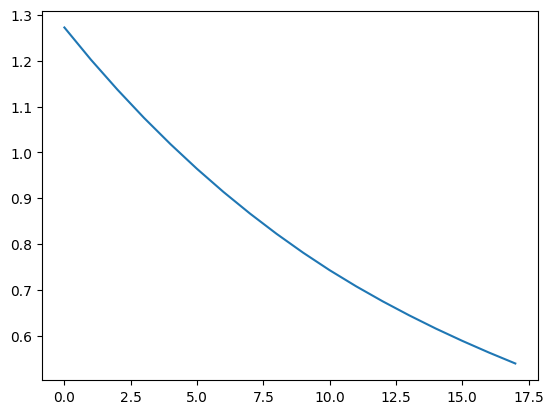

In [34]:
# Import seaborn for plotting
import seaborn as sns
# Plot the training loss over epochs
sns.lineplot(x=history.epoch, y=history.history['loss'])

In [35]:
# Make predictions on the test data
y_pred = model.predict(X_test)
# Create a DataFrame for the predictions
prediction = pd.DataFrame(y_pred, columns=y.columns)
# Display the predictions
prediction

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


,0,1,2
0,0.129048,0.739262,0.131690
1,0.102722,0.057688,0.839591
2,0.219609,0.178791,0.601601
3,0.111356,0.019331,0.869312
4,0.165986,0.487329,0.346685
5,0.625339,0.221950,0.152711
6,0.527345,0.379227,0.093428
7,0.159368,0.099596,0.741036
8,0.801946,0.087942,0.110111
9,0.212209,0.075926,0.711865


In [36]:
# Get the predicted species by finding the class with the highest probability
predicted_species = prediction.idxmax(axis="columns")
predicted_species

,0
0,1
1,2
2,2
3,2
4,1
5,0
6,0
7,2
8,0
9,2


In [37]:
# Import confusion_matrix and accuracy_score for model evaluation
from sklearn.metrics import confusion_matrix, accuracy_score

# Get the true species from the test set
true_species = y_test.idxmax(axis="columns")

# Compute the confusion matrix
matrix = confusion_matrix(true_species, predicted_species)
# Display the confusion matrix
print(matrix)

[[11  1  0]
 [ 4  9  1]
 [ 1  0  9]]


In [38]:
# Calculate and print the accuracy of the model
accuracy_score(true_species, predicted_species)

0.8055555555555556